# Classificação de desempenho de estudantes

#### Resumo
Utilizar o Random Forest Classifier e KNN variando o "K" para prever se algum estudante completou o curso de preparação para o teste "test preparation course". Para isto, vamos utilizar como métricas as notas de Matemática, Leitura e Redação.
Após os resultados, o dataframe será balanceado através de downsample, utilizando a biblioteca *_Resample_* da *_sklearns_*
E será executado novamente os algorítimos Random Forest e KNN com intuito de verificar diferenças no desempenho.

###### O dataframe
Parametros: sexo, raça/etinia, nível de educação parental, tipo do almoço, notas em Matemática, Leitura e Redação.

In [1]:
#Iportando bibliotecas
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline

In [2]:
dataframe = pd.read_csv(
    filepath_or_buffer = "StudentsPerformance.csv", 
    header = 0, 
)

In [3]:
#Cabeçalho do Dataframe
dataframe.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
dataframe.count()

gender                         1000
race/ethnicity                 1000
parental level of education    1000
lunch                          1000
test preparation course        1000
math score                     1000
reading score                  1000
writing score                  1000
dtype: int64

In [5]:
dataframe

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


### Verificar se há valores nulos no dataframe

In [6]:
dataframe.isnull().sum()
#não há dado nulo 

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### Plotando dispersão de dados

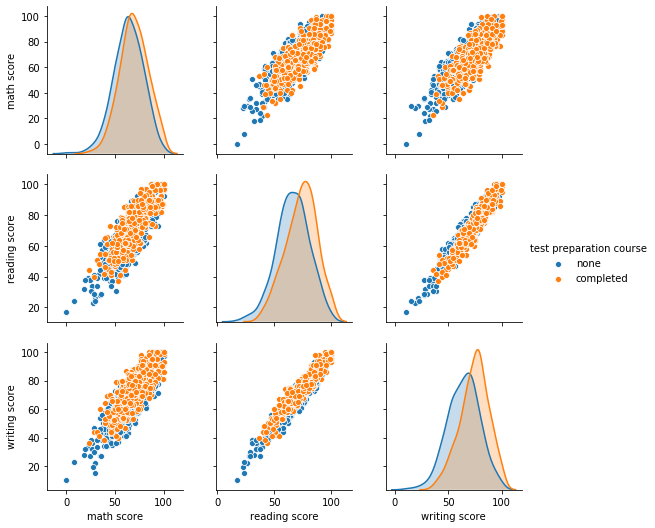

In [7]:
sb.pairplot(dataframe, hue='test preparation course')
#dispersão com base no curso de preparação

Os estudantes que fizeram o curso obtiveram melhores resultados em Reading e Writing, já em matemática, a diferença de desempenho não foi tão alta em relaçao as outras matérias

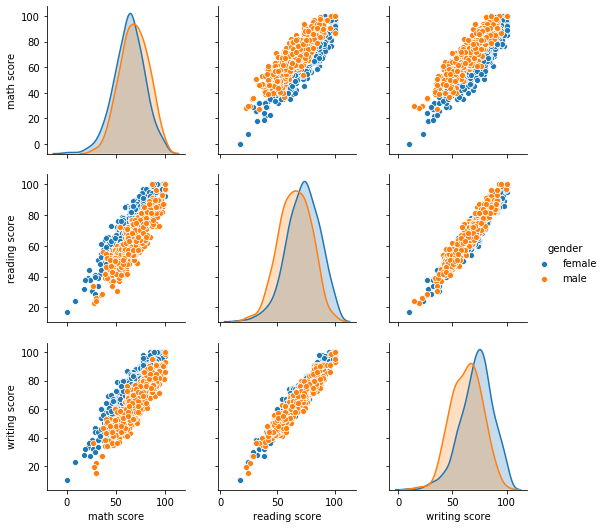

In [8]:
sb.pairplot(dataframe, hue='gender')
#dispersão com base no genero

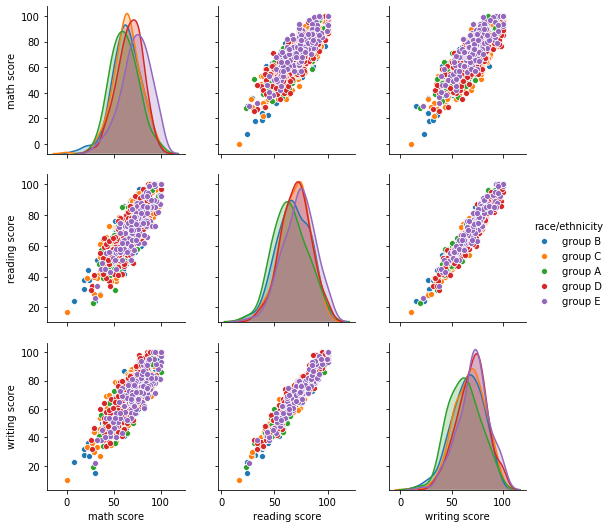

In [9]:
sb.pairplot(dataframe, hue='race/ethnicity')
#dispersão com base na raça/etinia

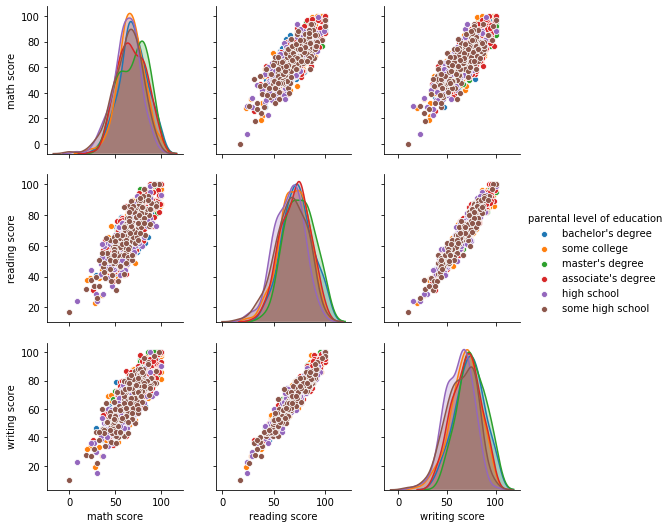

In [10]:
sb.pairplot(dataframe, hue='parental level of education')
#dispersão com base no nível educacional dos responsáveis

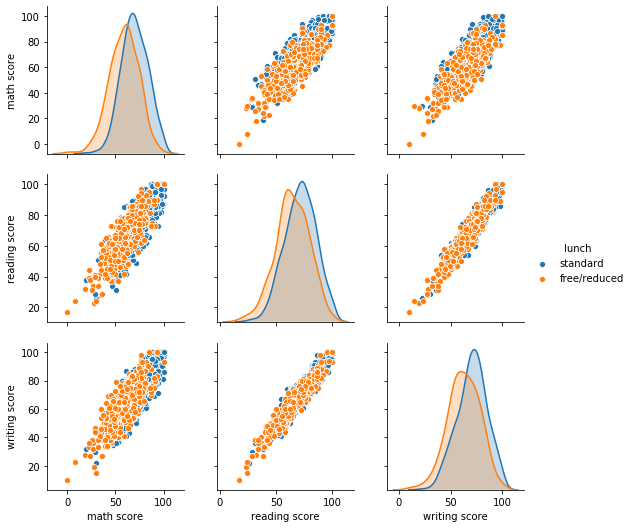

In [11]:
sb.pairplot(dataframe, hue='lunch')
#dispersão com base no almoço do aluno

#### Criando dataframes de entradas e saídas.

In [12]:
# selecionando colunas "math score' 'reading score' e 'writing score'
ML_DataPoints = pd.read_csv(
    filepath_or_buffer = "StudentsPerformance.csv", 
    header = 0, 
    usecols = ['math score',
               'reading score',
               'writing score'] # colunas de pontuação
)
ML_DataPoints

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75
...,...,...,...
995,88,99,95
996,62,55,55
997,59,71,65
998,68,78,77


In [13]:
#Criando dataframe para os rótulos
ML_Labels = pd.read_csv(
    filepath_or_buffer = "StudentsPerformance.csv",
    header = 0,
    usecols = ['test preparation course'] # coluna para saída dos dados
)

#### Pré processamento

In [14]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [15]:
# min max scaler
#Transforma recursos dimensionando para um determinado intervalo 
MNScaler = MinMaxScaler()
MNScaler.fit(ML_DataPoints) # fit math, reading, writing scores
T_DataPoints = MNScaler.transform(ML_DataPoints) # transformar os scores

###### Transformar os dados da coluna em valores entre 0 e 1.

In [16]:
LEncoder = LabelEncoder()
LEncoder.fit(ML_Labels)
T_Labels = LEncoder.transform(ML_Labels)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\label.py:219: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\label.py:252: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [17]:
ML_Labels.describe()

,test preparation course
count,1000
unique,2
top,none
freq,642


###### Dividir dados em treino e teste

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
XTrain, XTest, YTrain, YTest = train_test_split(T_DataPoints, T_Labels, random_state = 22)

#### Random Forest Classifier

###### método de aprendizado conjunto para classificação, regressão e outras tarefas que operam construindo uma infinidade de árvores de decisão no momento do treinamento e gerando a classe que é o modo das classes ou a previsão média das árvores individuais.

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
RandomForest = RandomForestClassifier(
    n_estimators = 10,
    random_state = 3
) 

In [22]:
RandomForest.fit(XTrain, YTrain) # fit entradas e saidas

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                       max_depth=None, max_features='auto', max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=3, verbose=0,
                       warm_start=False)

In [23]:
RandomForest.score(XTrain, YTrain) # média da acurácia treino

0.9693333333333334

In [24]:
RandomForest.score(XTest, YTest) #média da acurácia teste

0.628

Para testar nossa IA, vamos criar um array com pontuações abaixo e acima da média para tentar prever.
o array de resultado necessita ser :            [0, 1, 1, 1, 1, 0, 0, 0, 0, 1] de acordo com o nosso dataframe

In [25]:
data_points= np.array ([
    [46, 42, 46], [90, 95, 93], [47, 57, 44], [76, 78, 75], [71,83, 78], #none --> 1
    [69, 90, 88], [88, 95, 92], [64, 64, 67], [78, 72, 70], [72, 72, 74]  # completed --> 0

])

In [26]:
T_Points = MNScaler.transform(data_points)

In [27]:
RandomForest.predict(T_Points)

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1])

###### O Random Forest acertou 10 resultados de 10 

# Classificador KNN 

O algoritmo k-vizinhos mais próximos (k-NN) é um método não-paramétrico utilizado para a classificação e regressão. Em ambos os casos, a entrada consiste em calcular a distância entre os k exemplos de treinamento mais próximos.

Na classificação com o k-NN, a saída é uma associação com uma classe. Um objeto é classificado pela votação majoritária da classe dos vizinhos, sendo o objeto atribuído à classe mais comum dentre seus k vizinhos mais próximos.


k é um inteiro positivo, tipicamente pequeno e impar.
Se k = 1, então o objeto é simplesmente atribuído à classe desse único vizinho mais próximo.

##### Importando Biblioteca

In [28]:
from sklearn.neighbors import KNeighborsClassifier

In [29]:
#criando o classificador com número de vizinhos = 3
knn = KNeighborsClassifier(n_neighbors=3)


##### Treinando o Knn

In [30]:
knn.fit(XTrain, YTrain)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=3, p=2,
                     weights='uniform')

In [31]:
data_points= np.array ([
    [46, 42, 46], [90, 95, 93], [47, 57, 44], [76, 78, 75], [71,83, 78], #none --> 1
    [69, 90, 88], [88, 95, 92], [64, 64, 67], [78, 72, 70], [72, 72, 74]  # completed --> 0

])

In [32]:
T_Points = MNScaler.transform(data_points)

In [33]:
knn.score(XTrain, YTrain)

0.812

In [34]:
knn.score(XTest, YTest)

0.644

In [35]:
knn.predict(T_Points)

array([0, 1, 1, 1, 1, 0, 0, 0, 1, 1])

###### O knn  acertou 9 resultados de 10 , vamos aumentar o número de vizinhos para ver o que acontece.

In [36]:
knn = KNeighborsClassifier(n_neighbors=5) #5 k vizinhos

##### Treinando o Knn  K = 5

In [37]:
knn.fit(XTrain, YTrain)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=5, p=2,
                     weights='uniform')

In [38]:
data_points= np.array ([
    [46, 42, 46], [90, 95, 93], [47, 57, 44], [76, 78, 75], [71,83, 78], #none --> 1
    [69, 90, 88], [88, 95, 92], [64, 64, 67], [78, 72, 70], [72, 72, 74]  # completed --> 0

])

In [39]:
T_Points = MNScaler.transform(data_points)

In [40]:
knn.score(XTrain, YTrain)
#score knn K= 3 : 0.812

0.768

In [41]:
knn.score(XTest, YTest)
#score knn k = 3 : 0.644

0.68

In [42]:
knn.predict(T_Points)

array([1, 0, 1, 1, 1, 0, 0, 1, 1, 1])

##### Aumentando o número de K vizinhos, o algorítimo obteve um score  mais baixo no treino , e mais alto no teste. O KNN  acertou 6 resultados de 10 

###  Balanceando o Dataframe através de downsample e verificar os resultados

In [43]:
dataframe

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [44]:
# primeiramente vamos transformar as Labels "none" e "completed" em dados numéricos
from sklearn.preprocessing import LabelEncoder
dataframe['test preparation course'] = LabelEncoder().fit_transform(dataframe['test preparation course'])

In [45]:
dataframe
# 1 Representa: NONE
# 0 Representa: Completed

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,1,72,72,74
1,female,group C,some college,standard,0,69,90,88
2,female,group B,master's degree,standard,1,90,95,93
3,male,group A,associate's degree,free/reduced,1,47,57,44
4,male,group C,some college,standard,1,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,0,88,99,95
996,male,group C,high school,free/reduced,1,62,55,55
997,female,group C,high school,free/reduced,0,59,71,65
998,female,group D,some college,standard,0,68,78,77


In [46]:
dataframe['test preparation course'].value_counts()

1    642
0    358
Name: test preparation course, dtype: int64

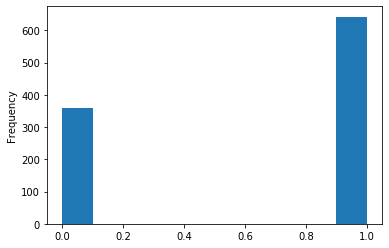

In [47]:
dataframe['test preparation course'].plot(kind = 'hist')

Há desbalanceamento.

Para resolver, vamos realizar Downsample para o menor número de saídas.

In [48]:
outputs_majority = dataframe[dataframe['test preparation course'] == 1]
outputs_minority = dataframe[dataframe['test preparation course'] == 0]

In [49]:
from sklearn.utils import resample 
#biblioteca para realizar o resample

outputs_majority_downsampled = resample(outputs_majority, replace = False, n_samples = 358, random_state = 123)

In [50]:
outputs_majority_downsampled['test preparation course'].value_counts()

1    358
Name: test preparation course, dtype: int64

In [51]:
dataframe_downsample = pd.concat([outputs_majority_downsampled, outputs_minority])
dataframe_downsample

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
79,female,group E,master's degree,standard,1,62,68,68
295,male,group B,associate's degree,free/reduced,1,67,62,60
243,male,group E,some college,standard,1,59,51,43
477,male,group D,associate's degree,standard,1,80,68,72
280,male,group D,high school,standard,1,53,52,42
...,...,...,...,...,...,...,...,...
990,male,group E,high school,free/reduced,0,86,81,75
991,female,group B,some high school,standard,0,65,82,78
995,female,group E,master's degree,standard,0,88,99,95
997,female,group C,high school,free/reduced,0,59,71,65


1    358
0    358
Name: test preparation course, dtype: int64

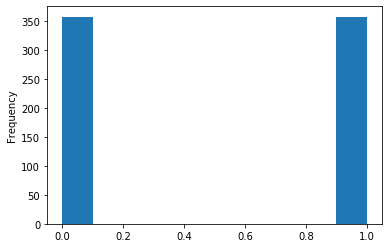

In [52]:
dataframe_downsample['test preparation course'].plot(kind = 'hist')
dataframe_downsample['test preparation course'].value_counts()

Com os dados balanceados através de downsample, vamos verificar o desempenho do KNN e o Random Forest classifier  

### Criar Dataframes de entrada e saída

In [53]:
# selecionando colunas "math score' 'reading score' e 'writing score'
colunaInput = ['math score',
               'reading score',
               'writing score']

ML_DataPoints = dataframe_downsample.filter(items = colunaInput)
ML_DataPoints

,math score,reading score,writing score
79,62,68,68
295,67,62,60
243,59,51,43
477,80,68,72
280,53,52,42
...,...,...,...
990,86,81,75
991,65,82,78
995,88,99,95
997,59,71,65


In [54]:
#Criando dataframe para os rótulos
colunaOutput = ['test preparation course']
ML_Labels = dataframe_downsample.filter(items = colunaOutput)
ML_Labels

,test preparation course
79,1
295,1
243,1
477,1
280,1
...,...
990,0
991,0
995,0
997,0


# Cópia do código para teste do Downsample

#### Pré processamento

In [55]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [56]:
# min max scaler
#Transforma recursos dimensionando para um determinado intervalo 
MNScaler = MinMaxScaler()
MNScaler.fit(ML_DataPoints) # fit math, reading, writing scores
T_DataPoints = MNScaler.transform(ML_DataPoints) # transformar os scores

###### Transformar os dados da coluna em valores entre 0 e 1.

In [57]:
LEncoder = LabelEncoder()
LEncoder.fit(ML_Labels)
T_Labels = LEncoder.transform(ML_Labels)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\label.py:219: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\label.py:252: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [58]:
ML_Labels.describe()

,test preparation course
count,716.00000
mean,0.50000
std,0.50035
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


###### Dividir dados em treino e teste

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
XTrain, XTest, YTrain, YTest = train_test_split(T_DataPoints, T_Labels, random_state = 22)

#### Random Forest Classifier

###### método de aprendizado conjunto para classificação, regressão e outras tarefas que operam construindo uma infinidade de árvores de decisão no momento do treinamento e gerando a classe que é o modo das classes ou a previsão média das árvores individuais.

In [61]:
from sklearn.ensemble import RandomForestClassifier

In [62]:
RandomForest = RandomForestClassifier(
    n_estimators = 10,
    random_state = 3
) 

In [63]:
RandomForest.fit(XTrain, YTrain) # fit entradas e saidas

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                       max_depth=None, max_features='auto', max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=3, verbose=0,
                       warm_start=False)

In [64]:
RandomForest.score(XTrain, YTrain) # média da acurácia treino
#Score passado : 0.9693333333333334

0.9776536312849162

In [65]:
RandomForest.score(XTest, YTest) #média da acurácia teste
#Score passado: 0.628

0.6201117318435754

Para testar nossa IA, vamos criar um array com pontuações abaixo e acima da média para tentar prever.
o array de resultado necessita ser :            [0, 1, 1, 1, 1, 0, 0, 0, 0, 1] de acordo com o nosso dataframe

In [66]:
data_points= np.array ([
    [46, 42, 46], [90, 95, 93], [47, 57, 44], [76, 78, 75], [71,83, 78], #none --> 1
    [69, 90, 88], [88, 95, 92], [64, 64, 67], [78, 72, 70], [72, 72, 74]  # completed --> 0

])

In [67]:
T_Points = MNScaler.transform(data_points)

In [68]:
RandomForest.predict(T_Points)

array([0, 1, 1, 0, 1, 0, 0, 1, 0, 1], dtype=int64)

###### O Random Forest acertou 8 resultados de 10 e obteve resultado de teste melhor depois do downsample


# Classificador KNN 

O algoritmo k-vizinhos mais próximos (k-NN) é um método não-paramétrico utilizado para a classificação e regressão. Em ambos os casos, a entrada consiste em calcular a distância entre os k exemplos de treinamento mais próximos.

Na classificação com o k-NN, a saída é uma associação com uma classe. Um objeto é classificado pela votação majoritária da classe dos vizinhos, sendo o objeto atribuído à classe mais comum dentre seus k vizinhos mais próximos.


k é um inteiro positivo, tipicamente pequeno e impar.
Se k = 1, então o objeto é simplesmente atribuído à classe desse único vizinho mais próximo.

##### Importando Biblioteca

In [69]:
from sklearn.neighbors import KNeighborsClassifier

In [70]:
#criando o classificador com número de vizinhos = 3
knn = KNeighborsClassifier(n_neighbors=3)


##### Treinando o Knn

In [71]:
knn.fit(XTrain, YTrain)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=3, p=2,
                     weights='uniform')

In [72]:
data_points= np.array ([
    [46, 42, 46], [90, 95, 93], [47, 57, 44], [76, 78, 75], [71,83, 78], #none --> 1
    [69, 90, 88], [88, 95, 92], [64, 64, 67], [78, 72, 70], [72, 72, 74]  # completed --> 0

])

In [73]:
T_Points = MNScaler.transform(data_points)

In [74]:
knn.score(XTrain, YTrain) 
# Score antes do downsample: 0.812

0.7895716945996276

In [75]:
knn.score(XTest, YTest)
# Score antes do downsample : 0.644

0.5810055865921788

In [76]:
knn.predict(T_Points)

array([0, 1, 1, 0, 1, 0, 0, 1, 1, 1], dtype=int64)

###### O knn acertou 7 resultados de 10 , vamos aumentar o número de vizinhos para ver o que acontece

In [77]:
knn = KNeighborsClassifier(n_neighbors=5) #5 k vizinhos

##### Treinando o Knn  K = 5

In [78]:
knn.fit(XTrain, YTrain)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=5, p=2,
                     weights='uniform')

In [79]:
data_points= np.array ([
    [46, 42, 46], [90, 95, 93], [47, 57, 44], [76, 78, 75], [71,83, 78], #none --> 1
    [69, 90, 88], [88, 95, 92], [64, 64, 67], [78, 72, 70], [72, 72, 74]  # completed --> 0

])

In [80]:
T_Points = MNScaler.transform(data_points)

In [81]:
knn.score(XTrain, YTrain) 
# Score antes do downsample : 0.768
# Score k = 3 : 0.7895716945996276

0.74487895716946

In [82]:
knn.score(XTest, YTest)
# Score antes do downsample : 0.68
# Score k = 3 : 0.5810055865921788

0.5363128491620112

In [83]:
knn.predict(T_Points)

array([0, 0, 1, 0, 1, 0, 0, 1, 0, 1], dtype=int64)

##### Aumentando o número de K vizinhos, o algorítimo obteve um score  mais baixo no treino e no teste. O KNN  acertou 7 resultados de 10 

# Conclusão

Após a execução dos algoritimos Random Forest e KNN, antes e depois do downsample, os melhores scores foram obtidos utilizando o Random Forest após downsample, apesar de ter acertado menos na predição do resultado.


# Trabalhos Futuros

testar outros métodos para balanceamento dos dados.
Verificar desempenho dos estudantes com relação a outros parametros: sexo; raça/etinia; nível de educação parental; tipo do almoço.